## 📦 1. Imports & Configuration

In [1]:
import requests
import pandas as pd
import numpy as np
import time
import warnings
import os                         
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✅ XGBoost available')
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost not installed — skipping')

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print('✅ LightGBM available')
except ImportError:
    LGB_AVAILABLE = False
    print('⚠️  LightGBM not installed — skipping')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import product

SYMBOL        = 'BTCUSDT'
INTERVAL_1M   = '1m'
TOTAL_BARS    = 43000       # ~30 days of 1-min data
HORIZON       = 15          # predict 15 min ahead
TRAIN_RATIO   = 0.70
RANDOM_STATE  = 42

TRADE_FEE     = 0.0004      # 0.04% per side (Binance maker/taker)
SLIPPAGE      = 0.0005      # 0.05% slippage per trade
ROUND_TRIP    = (TRADE_FEE + SLIPPAGE) * 2   # total cost per round-trip

PLOT_DIR = os.path.join(os.getcwd(), 'Plot_Images')
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'\n📊 Config loaded: {SYMBOL} | {INTERVAL_1M} | horizon={HORIZON}min')
print(f'💸 Round-trip cost: {ROUND_TRIP*100:.3f}%')
print(f'📁 Plot directory : {PLOT_DIR}')   

✅ XGBoost available
✅ LightGBM available

📊 Config loaded: BTCUSDT | 1m | horizon=15min
💸 Round-trip cost: 0.180%
📁 Plot directory : c:\Python\Crypto_Prediction_Practical\Plot_Images


## 📡 2. Real-Time Data Fetch from Binance

**What we do:** Pull the last ~30 days of 1-minute OHLCV data from Binance public API.  
**Why paginate:** Binance returns max 1000 bars per request, so we loop backward in time until we have enough data.

In [2]:
def fetch_binance_data(symbol=SYMBOL, interval=INTERVAL_1M, total_bars=TOTAL_BARS):
 
    BINANCE_URL = 'https://api.binance.com/api/v3/klines'
    all_data    = []
    end_time    = None

    print(f'📡 Fetching {total_bars:,} bars for {symbol} ({interval})...')

    while len(all_data) < total_bars:
        params = {'symbol': symbol, 'interval': interval, 'limit': 1000}
        if end_time:
            params['endTime'] = end_time

        resp = requests.get(BINANCE_URL, params=params, timeout=15)
        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_data = data + all_data
        end_time = data[0][0] - 1
        print(f'  Fetched: {len(all_data):,} / {total_bars:,}', end='\r')
        time.sleep(0.1)   

    print(f'\n✅ Fetch complete!')

    df = pd.DataFrame(all_data, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_vol', 'trades',
        'taker_buy_base', 'taker_buy_quote', 'ignore'
    ])
    df = df[['timestamp', 'open', 'high', 'low', 'close', 'volume']]
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df[['open','high','low','close','volume']] = df[['open','high','low','close','volume']].astype(float)
    df = df.sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)

    print(f'Shape      : {df.shape}')
    print(f'Date range : {df.timestamp.min()} → {df.timestamp.max()}')
    print(f'Price range: ${df.close.min():,.0f} → ${df.close.max():,.0f}')
    return df

df_raw = fetch_binance_data()
df_raw.head()

📡 Fetching 43,000 bars for BTCUSDT (1m)...
  Fetched: 43,000 / 43,000
✅ Fetch complete!
Shape      : (43000, 6)
Date range : 2026-02-21 08:12:00 → 2026-03-23 04:51:00
Price range: $62,561 → $75,982


,timestamp,open,high,low,close,volume
0,2026-02-21 08:12:00,67900.00,67910.50,67900.00,67910.49,1.98507
1,2026-02-21 08:13:00,67910.49,67910.50,67910.49,67910.49,0.61242
2,2026-02-21 08:14:00,67910.49,67910.50,67910.49,67910.49,3.26241
3,2026-02-21 08:15:00,67910.49,67920.44,67910.49,67920.43,1.74067
4,2026-02-21 08:16:00,67920.44,67950.00,67920.43,67942.02,5.02732


## 🔧 3. Feature Engineering

### Why each feature group matters:
| Group | Features | Purpose |
|---|---|---|
| **RSI** | rsi_14, rsi_7 | Overbought/oversold momentum |
| **Bollinger Bands** | bb_width, bb_pctb, bb_squeeze | Volatility & mean-reversion signals |
| **EMA** | ema_9/21/50, ema_cross | Trend direction & speed |
| **VWAP** | price_vs_vwap | Institutional price anchor |
| **Volume** | vol_spike, vol_ratio | Confirms price moves |
| **Momentum** | mom_1/3/5/10/15 | Rate of price change |
| **Multi-TF** | features on 5m/15m resampled | Broader context for short-term signals |
| **Candle** | body, wick_ratio, is_bullish | Microstructure patterns |
| **Lag** | lag_1/2/3 of key features | Sequence information without lookahead |

In [3]:
def compute_rsi(series, period):
    delta = series.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/period, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/period, adjust=False).mean()
    return 100 - (100 / (1 + gain / (loss + 1e-9)))


def engineer_features_1m(df):
    d = df.copy()

    # ── RSI ──────────────────────────────────────────────────────
    d['rsi_14']      = compute_rsi(d['close'], 14)
    d['rsi_7']       = compute_rsi(d['close'], 7)
    d['rsi_slope']   = d['rsi_14'].diff(3)          # RSI acceleration

    # ── Bollinger Bands ──────────────────────────────────────────
    mid              = d['close'].rolling(20).mean()
    std              = d['close'].rolling(20).std()
    d['bb_upper']    = mid + 2 * std
    d['bb_lower']    = mid - 2 * std
    d['bb_width']    = (d['bb_upper'] - d['bb_lower']) / (mid + 1e-9)
    d['bb_pctb']     = (d['close'] - d['bb_lower']) / (d['bb_upper'] - d['bb_lower'] + 1e-9)
    
    # BB Squeeze: width < 20-period average width
    d['bb_squeeze']  = (d['bb_width'] < d['bb_width'].rolling(20).mean()).astype(int)

    # ── EMAs ─────────────────────────────────────────────────────
    d['ema_9']       = d['close'].ewm(span=9,  adjust=False).mean()
    d['ema_21']      = d['close'].ewm(span=21, adjust=False).mean()
    d['ema_50']      = d['close'].ewm(span=50, adjust=False).mean()
    d['ema_cross']   = d['ema_9'] - d['ema_21']                        # +ve = bullish
    d['ema_cross_chg']= d['ema_cross'].diff()                          # cross direction change
    d['price_ema9']  = (d['close'] - d['ema_9'])  / (d['ema_9']  + 1e-9)
    d['price_ema21'] = (d['close'] - d['ema_21']) / (d['ema_21'] + 1e-9)

    # ── VWAP (reset daily) ───────────────────────────────────────
    # ⚠️  Cumsum VWAP drifts over 30 days — use daily reset
    d['date']        = d['timestamp'].dt.date
    tp               = (d['high'] + d['low'] + d['close']) / 3
    d['cum_tp_vol']  = (tp * d['volume']).groupby(d['date']).cumsum()
    d['cum_vol']     = d['volume'].groupby(d['date']).cumsum()
    d['vwap']        = d['cum_tp_vol'] / (d['cum_vol'] + 1e-9)
    d['price_vs_vwap'] = (d['close'] - d['vwap']) / (d['vwap'] + 1e-9)
    d.drop(columns=['date', 'cum_tp_vol', 'cum_vol'], inplace=True)

    # ── Volume ───────────────────────────────────────────────────
    d['vol_ma20']    = d['volume'].rolling(20).mean()
    d['vol_spike']   = d['volume'] / (d['vol_ma20'] + 1e-9)
    d['vol_ratio5']  = d['volume'].rolling(5).mean() / (d['vol_ma20'] + 1e-9)
    d['vol_trend']   = d['vol_ma20'].pct_change(5)   # volume trend direction

    # ── Momentum ─────────────────────────────────────────────────
    for lag in [1, 3, 5, 10, 15]:
        d[f'mom_{lag}'] = d['close'].pct_change(lag)

    # ── Volatility ───────────────────────────────────────────────
    d['volatility_10'] = d['close'].pct_change().rolling(10).std()
    d['atr_14']        = (
        pd.concat([
            d['high'] - d['low'],
            (d['high'] - d['close'].shift()).abs(),
            (d['low']  - d['close'].shift()).abs()
        ], axis=1).max(axis=1)
        .rolling(14).mean()
    )
    d['atr_pct']       = d['atr_14'] / (d['close'] + 1e-9)
    d['high_low_pct']  = (d['high'] - d['low']) / (d['close'] + 1e-9)

    # ── Candle structure ─────────────────────────────────────────
    candle_range       = (d['high'] - d['low'] + 1e-9)
    d['body']          = (d['close'] - d['open']) / candle_range
    d['upper_wick']    = (d['high'] - d[['open','close']].max(axis=1)) / candle_range
    d['lower_wick']    = (d[['open','close']].min(axis=1) - d['low']) / candle_range
    d['is_bullish']    = (d['close'] > d['open']).astype(int)
    d['is_doji']       = (d['body'].abs() < 0.1).astype(int)

    # ── Lag features (NO leakage — shift by 1+) ──────────────────
    for lag in [1, 2, 3]:
        d[f'rsi_lag{lag}']     = d['rsi_14'].shift(lag)
        d[f'vol_lag{lag}']     = d['vol_spike'].shift(lag)
        d[f'mom1_lag{lag}']    = d['mom_1'].shift(lag)
        d[f'vwap_lag{lag}']    = d['price_vs_vwap'].shift(lag)

    return d


def engineer_features_multitf(df):
    df = df.set_index('timestamp')

    def resample_ohlcv(df_indexed, rule):
        return df_indexed.resample(rule).agg({
            'open':   'first',
            'high':   'max',
            'low':    'min',
            'close':  'last',
            'volume': 'sum'
        }).dropna()

    for tf, label in [('5min', '5m'), ('15min', '15m')]:
        tf_df        = resample_ohlcv(df, tf)
        tf_df[f'rsi_{label}']   = compute_rsi(tf_df['close'], 14)
        tf_df[f'ema9_{label}']  = tf_df['close'].ewm(span=9,  adjust=False).mean()
        tf_df[f'ema21_{label}'] = tf_df['close'].ewm(span=21, adjust=False).mean()
        tf_df[f'cross_{label}'] = tf_df[f'ema9_{label}'] - tf_df[f'ema21_{label}']
        vol_ma                   = tf_df['volume'].rolling(20).mean()
        tf_df[f'volspk_{label}']= tf_df['volume'] / (vol_ma + 1e-9)
        mid                      = tf_df['close'].rolling(20).mean()
        std                      = tf_df['close'].rolling(20).std()
        tf_df[f'bbw_{label}']   = (4 * std) / (mid + 1e-9)
        tf_df[f'mom3_{label}']  = tf_df['close'].pct_change(3)

        keep_cols = [c for c in tf_df.columns if label in c]
        # Shift by 1 BEFORE reindex — prevents lookahead
        tf_reindexed = (
            tf_df[keep_cols]
            .shift(1)
            .reindex(df.index, method='ffill')
        )
        df = df.join(tf_reindexed)

    return df.reset_index()


def engineer_all_features(df):
    df = engineer_features_1m(df)
    df = engineer_features_multitf(df)
    df = df.dropna().reset_index(drop=True)
    print(f'Features engineered. Shape: {df.shape} | Features: {df.shape[1] - 6}')
    return df


df = engineer_all_features(df_raw)
df.head(3)

Features engineered. Shape: (42712, 67) | Features: 61


,timestamp,open,high,low,close,volume,rsi_14,rsi_7,rsi_slope,bb_upper,...,volspk_5m,bbw_5m,mom3_5m,rsi_15m,ema9_15m,ema21_15m,cross_15m,volspk_15m,bbw_15m,mom3_15m
0,2026-02-21 13:00:00,68203.42,68203.42,68169.99,68170.0,11.20568,64.287540,56.747795,-8.340756,68251.338763,...,0.688632,0.004747,0.00253,70.424166,68101.07871,68082.663377,18.415334,1.114351,0.006402,0.00314
1,2026-02-21 13:01:00,68169.99,68174.91,68165.05,68174.9,1.74188,65.140074,58.690249,-9.715752,68252.918413,...,0.688632,0.004747,0.00253,70.424166,68101.07871,68082.663377,18.415334,1.114351,0.006402,0.00314
2,2026-02-21 13:02:00,68174.91,68174.91,68174.90,68174.9,1.17129,65.140074,58.690249,-10.929561,68252.360197,...,0.688632,0.004747,0.00253,70.424166,68101.07871,68082.663377,18.415334,1.114351,0.006402,0.00314


## 🏷️ 4. Label Creation (Leak-Free)

**Rule:** `target = 1 (UP)` if `close(t+15) > close(t)` else `0 (DOWN)`

**Important:** We use `.shift(-15)` on `close` — this is intentional and NOT leakage because the target is what we're trying to predict, not a feature. We drop the last 15 rows since their future price doesn't exist.

In [4]:
def create_labels(df, horizon=HORIZON):
    df = df.copy()
    df['future_close'] = df['close'].shift(-horizon)
    df['target']       = (df['future_close'] > df['close']).astype(int)
    df = df.dropna(subset=['future_close']).reset_index(drop=True)
    return df

df = create_labels(df, horizon=HORIZON)

up   = df['target'].sum()
down = len(df) - up
print(f'Total rows  : {len(df):,}')
print(f'UP   (1) ✅ : {up:,}  ({up/len(df)*100:.1f}%)')
print(f'DOWN (0) ❌ : {down:,}  ({down/len(df)*100:.1f}%)')
print(f'Class imbalance ratio: {max(up,down)/min(up,down):.2f}x')

Total rows  : 42,697
UP   (1) ✅ : 21,154  (49.5%)
DOWN (0) ❌ : 21,543  (50.5%)
Class imbalance ratio: 1.02x


## ✂️ 5. Walk-Forward Train/Test Split

**Why NOT random split:** Financial data has temporal autocorrelation. Random splitting allows the model to "see the future" during training (data leakage). We always split on time: **first 70% = train, last 30% = test**.

This simulates a real-world scenario where you train on historical data and trade on unseen future data.

In [5]:
# ── Define feature columns ────────────────────────────────────
EXCLUDE = {
    'timestamp', 'open', 'high', 'low', 'close', 'volume',
    'future_close', 'target',
    'bb_upper', 'bb_lower', 'ema_9', 'ema_21', 'ema_50',
    'vwap', 'vol_ma20', 'atr_14', 'cum_tp_vol', 'cum_vol'
}
feature_cols = [c for c in df.columns if c not in EXCLUDE]

print(f'Total features used : {len(feature_cols)}')
print('Features:', feature_cols)

split     = int(len(df) * TRAIN_RATIO)
train     = df.iloc[:split].copy()
test      = df.iloc[split:].copy()

X_train   = train[feature_cols]
y_train   = train['target']
X_test    = test[feature_cols]
y_test    = test['target']

print(f'\nTrain: {len(train):,} rows | {train.timestamp.min().date()} → {train.timestamp.max().date()}')
print(f'Test : {len(test):,} rows  | {test.timestamp.min().date()} → {test.timestamp.max().date()}')
print(f'Train UP%: {y_train.mean()*100:.1f}% | Test UP%: {y_test.mean()*100:.1f}%')

Total features used : 53
Features: ['rsi_14', 'rsi_7', 'rsi_slope', 'bb_width', 'bb_pctb', 'bb_squeeze', 'ema_cross', 'ema_cross_chg', 'price_ema9', 'price_ema21', 'price_vs_vwap', 'vol_spike', 'vol_ratio5', 'vol_trend', 'mom_1', 'mom_3', 'mom_5', 'mom_10', 'mom_15', 'volatility_10', 'atr_pct', 'high_low_pct', 'body', 'upper_wick', 'lower_wick', 'is_bullish', 'is_doji', 'rsi_lag1', 'vol_lag1', 'mom1_lag1', 'vwap_lag1', 'rsi_lag2', 'vol_lag2', 'mom1_lag2', 'vwap_lag2', 'rsi_lag3', 'vol_lag3', 'mom1_lag3', 'vwap_lag3', 'rsi_5m', 'ema9_5m', 'ema21_5m', 'cross_5m', 'volspk_5m', 'bbw_5m', 'mom3_5m', 'rsi_15m', 'ema9_15m', 'ema21_15m', 'cross_15m', 'volspk_15m', 'bbw_15m', 'mom3_15m']

Train: 29,887 rows | 2026-02-21 → 2026-03-14
Test : 12,810 rows  | 2026-03-14 → 2026-03-23
Train UP%: 49.5% | Test UP%: 49.7%


## 🤖 6. Model Training & Comparison

We train multiple models and compare them. Key design choices:
- **LogisticRegression:** Baseline with StandardScaler (required for LR)
- **RandomForest:** Ensemble, handles non-linear relationships, no scaling needed
- **GradientBoosting:** Sequential boosting, excellent on tabular data
- **XGBoost / LightGBM:** State-of-the-art gradient boosting (if installed)

**class_weight / scale_pos_weight:** If UP/DOWN is imbalanced, we balance it to prevent model bias toward the majority class.

In [6]:
# ── Class imbalance weight ────────────────────────────────────
n_neg     = (y_train == 0).sum()
n_pos     = (y_train == 1).sum()
spw       = n_neg / n_pos   # scale_pos_weight for XGB
print(f'Scale pos weight (for XGB): {spw:.3f}')

models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=50,    # prevents overfitting on noisy data
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),
}

if XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE
    )

if LGB_AVAILABLE:
    models['LightGBM'] = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        verbose=-1
    )

trained = {}
for name, model in models.items():
    print(f'🔧 Training {name}...', end=' ')
    t0 = time.time()
    model.fit(X_train, y_train)
    trained[name] = model
    print(f'done in {time.time()-t0:.1f}s')

print('\n✅ All models trained!')

Scale pos weight (for XGB): 1.020
🔧 Training LogisticRegression... done in 1.4s
🔧 Training RandomForest... done in 31.5s
🔧 Training GradientBoosting... done in 218.7s
🔧 Training XGBoost... done in 5.2s
🔧 Training LightGBM... done in 2.7s

✅ All models trained!


## 📊 7. Full Evaluation — Metrics, Confusion Matrix, Feature Importance

In [7]:
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    return {
        'Model':     name,
        'Accuracy':  acc,
        'Precision': prec,
        'Recall':    rec,
        'F1':        f1,
        'ROC-AUC':   auc,
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }

results = {}
for name, model in trained.items():
    results[name] = evaluate_model(name, model, X_test, y_test)

summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'y_proba']}
    for r in results.values()
]).set_index('Model').sort_values('F1', ascending=False)

print('\n' + '='*65)
print('          MODEL COMPARISON RESULTS')
print('='*65)
print(summary.to_string(float_format='{:.4f}'.format))
print('='*65)

best_model_name = summary.index[0]
print(f'\n🏆 Best Model by F1: {best_model_name}')


          MODEL COMPARISON RESULTS
                    Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                          
XGBoost               0.5137     0.5113  0.4717 0.4907   0.5245
LightGBM              0.5159     0.5147  0.4423 0.4758   0.5273
GradientBoosting      0.5123     0.5120  0.3851 0.4396   0.5157
RandomForest          0.5261     0.5358  0.3425 0.4179   0.5347
LogisticRegression    0.5166     0.5217  0.3207 0.3972   0.5302

🏆 Best Model by F1: XGBoost


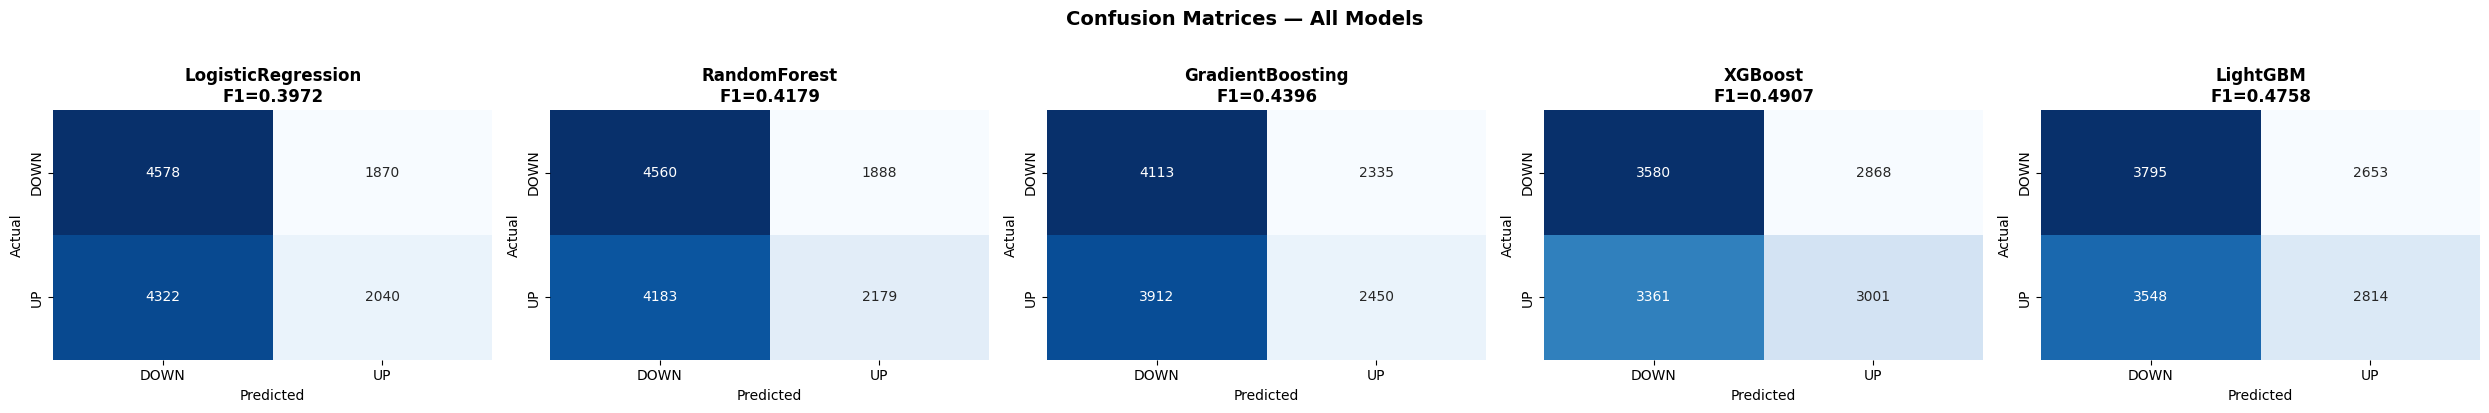

✅ Saved confusion_matrices.png


In [8]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['DOWN', 'UP'],
        yticklabels=['DOWN', 'UP'],
        ax=ax, cbar=False
    )
    f1 = results[name]['F1']
    ax.set_title(f'{name}\nF1={f1:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved confusion_matrices.png')

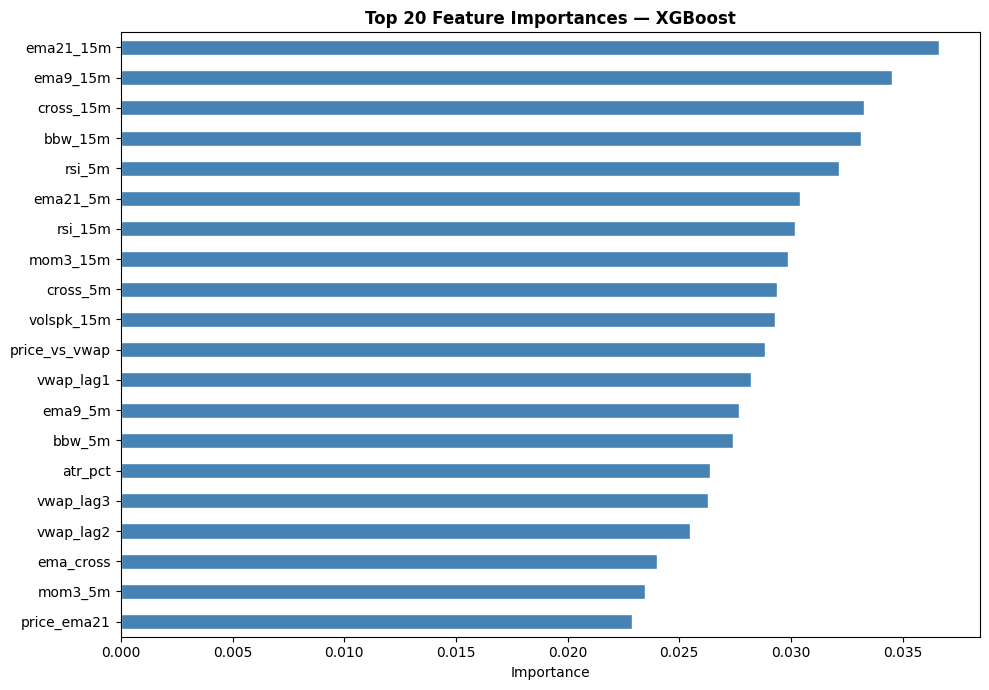

✅ Saved feature_importance.png


In [9]:
# ── Feature Importance — Best Model ──────────────────────────
best_model = trained[best_model_name]

# Extract importances (handle Pipeline wrapper)
clf = best_model.named_steps['clf'] if hasattr(best_model, 'named_steps') else best_model
if hasattr(clf, 'feature_importances_'):
    imp = pd.Series(clf.feature_importances_, index=feature_cols)
    top20 = imp.nlargest(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    top20.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved feature_importance.png')
else:
    # Logistic Regression coefficients
    coef = pd.Series(np.abs(clf.coef_[0]), index=feature_cols).nlargest(20)
    fig, ax = plt.subplots(figsize=(10, 7))
    coef.sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title('Top 20 Feature Coefficients (abs) — LogisticRegression', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 💹 8. Backtesting with Transaction Costs & Slippage

**Backtesting logic:**
- On each test bar, if model predicts **UP (1)** → go LONG (buy)
- If model predicts **DOWN (0)** → go SHORT (sell)
- Each position is held for exactly **15 minutes** (the prediction horizon)
- Each trade incurs: `fee (0.04%) + slippage (0.05%)` per side = **0.3% round-trip**

**Why this matters:** A model with 52% accuracy can still be UNPROFITABLE after costs!

In [10]:
def backtest(
    y_pred, y_proba, test_df,
    fee=TRADE_FEE,
    slippage=SLIPPAGE,
    confidence_threshold=0.55,
    position_size=0.10,          
    atr_min_pct=0.0025,          
    initial_capital=10_000.0
):
    cost_per_rt = (fee + slippage) * 2
    capital     = initial_capital
    equity_curve= [capital]
    trades      = []

    prices  = test_df['close'].values
    futures = test_df['future_close'].values
    times   = test_df['timestamp'].values

    if 'atr_pct' in test_df.columns:
        atrs = test_df['atr_pct'].fillna(0).values
    else:
        atrs = ((test_df['high'] - test_df['low']) / (test_df['close'] + 1e-9)).fillna(0).values
        print("⚠️  atr_pct missing — using high/low range proxy")

    n_skipped_conf = 0
    n_skipped_atr  = 0
    n_traded       = 0

    for i in range(len(y_pred)):
        pred      = y_pred[i]
        prob      = y_proba[i]
        price_in  = prices[i]
        price_out = futures[i]
        atr_i     = atrs[i]

        conf = prob if pred == 1 else (1 - prob)
        if conf < confidence_threshold:
            n_skipped_conf += 1
            equity_curve.append(capital)
            continue

        if atr_i < atr_min_pct:
            n_skipped_atr += 1
            equity_curve.append(capital)
            continue

        if pred == 1:
            raw_ret = (price_out - price_in) / (price_in + 1e-9)
        else:
            raw_ret = (price_in - price_out) / (price_in + 1e-9)

        net_ret   = raw_ret - cost_per_rt
        trade_pnl = capital * position_size * net_ret 
        capital   = max(capital + trade_pnl, 0)
        equity_curve.append(capital)
        n_traded += 1

        trades.append({
            'time':       times[i],
            'direction':  'LONG' if pred == 1 else 'SHORT',
            'price_in':   price_in,
            'price_out':  price_out,
            'raw_ret':    raw_ret,
            'net_ret':    net_ret,
            'pnl':        trade_pnl,
            'capital':    capital,
            'confidence': conf,
            'atr_pct':    atr_i
        })

    print(f"  Skipped low-confidence : {n_skipped_conf:,}")
    print(f"  Skipped low-ATR        : {n_skipped_atr:,}")
    print(f"  Trades executed        : {n_traded:,}")

    trades_df = pd.DataFrame(trades)

    if len(trades_df) == 0:
        print("⚠️  No trades taken. Re-running with relaxed filters...")
        return backtest(
            y_pred, y_proba, test_df,
            fee=fee, slippage=slippage,
            confidence_threshold=0.52,
            position_size=position_size,
            atr_min_pct=0.001,
            initial_capital=initial_capital
        )

    wins     = (trades_df['net_ret'] > 0).sum()
    win_rate = wins / len(trades_df)
    total_ret = (capital - initial_capital) / initial_capital * 100

    gross_profit = trades_df[trades_df['pnl'] > 0]['pnl'].sum()
    gross_loss   = trades_df[trades_df['pnl'] < 0]['pnl'].abs().sum()
    pf = gross_profit / (gross_loss + 1e-9)

    mean_r = trades_df['net_ret'].mean()
    std_r  = trades_df['net_ret'].std() + 1e-9
    sharpe = (mean_r / std_r) * np.sqrt(35040)

    eq      = pd.Series([initial_capital] + list(trades_df['capital']))
    max_dd  = ((eq - eq.cummax()) / (eq.cummax() + 1e-9)).min() * 100

    summary = {
        'Total Trades':      len(trades_df),
        'Win Rate':          win_rate,
        'Profit Factor':     pf,
        'Total Return (%)':  total_ret,
        'Sharpe Ratio':      sharpe,
        'Max Drawdown (%)':  max_dd,
        'Avg PnL/Trade ($)': trades_df['pnl'].mean(),
        'Final Capital ($)': capital
    }
    return trades_df, summary, equity_curve


bt_results = {}
for name, res in results.items():
    print(f"\n── {name} ──")
    trades_df, summary, eq_curve = backtest(
        res['y_pred'], res['y_proba'], test
    )
    bt_results[name] = {'trades': trades_df, 'summary': summary, 'equity': eq_curve}

print('\n' + '='*95)
print('                          BACKTESTING RESULTS  |  Capital: $10,000')
print('='*95)
bt_summary_rows = []
for name, bt in bt_results.items():
    s = bt['summary']
    if s:
        bt_summary_rows.append({
            'Model':         name,
            'Trades':        s['Total Trades'],
            'Win Rate':      f"{s['Win Rate']*100:.1f}%",
            'Profit Factor': f"{s['Profit Factor']:.3f}",
            'Total Return':  f"{s['Total Return (%)']:+.2f}%",
            'Sharpe':        f"{s['Sharpe Ratio']:.3f}",
            'Max DD':        f"{s['Max Drawdown (%)']:.2f}%",
            'Final Capital': f"${s['Final Capital ($)']:,.2f}"
        })

print(pd.DataFrame(bt_summary_rows).to_string(index=False))
print('='*95)
print(f'\n📌 Position size  : 10% of capital per trade')
print(f'📌 Round-trip cost: {ROUND_TRIP*100:.3f}%  (fee={TRADE_FEE*100:.2f}% + slippage={SLIPPAGE*100:.2f}% × 2 sides)')


── LogisticRegression ──
  Skipped low-confidence : 8,818
  Skipped low-ATR        : 3,970
  Trades executed        : 22

── RandomForest ──
  Skipped low-confidence : 5,454
  Skipped low-ATR        : 7,350
  Trades executed        : 6

── GradientBoosting ──
  Skipped low-confidence : 3,967
  Skipped low-ATR        : 8,818
  Trades executed        : 25

── XGBoost ──
  Skipped low-confidence : 3,276
  Skipped low-ATR        : 9,508
  Trades executed        : 26

── LightGBM ──
  Skipped low-confidence : 2,918
  Skipped low-ATR        : 9,867
  Trades executed        : 25

                          BACKTESTING RESULTS  |  Capital: $10,000
             Model  Trades Win Rate Profit Factor Total Return   Sharpe Max DD Final Capital
LogisticRegression      22    40.9%         0.795       -0.08%  -18.608 -0.26%     $9,991.64
      RandomForest       6    16.7%         0.343       -0.08%  -77.770 -0.11%     $9,992.49
  GradientBoosting      25     8.0%         0.084       -0.82% -178.144 -

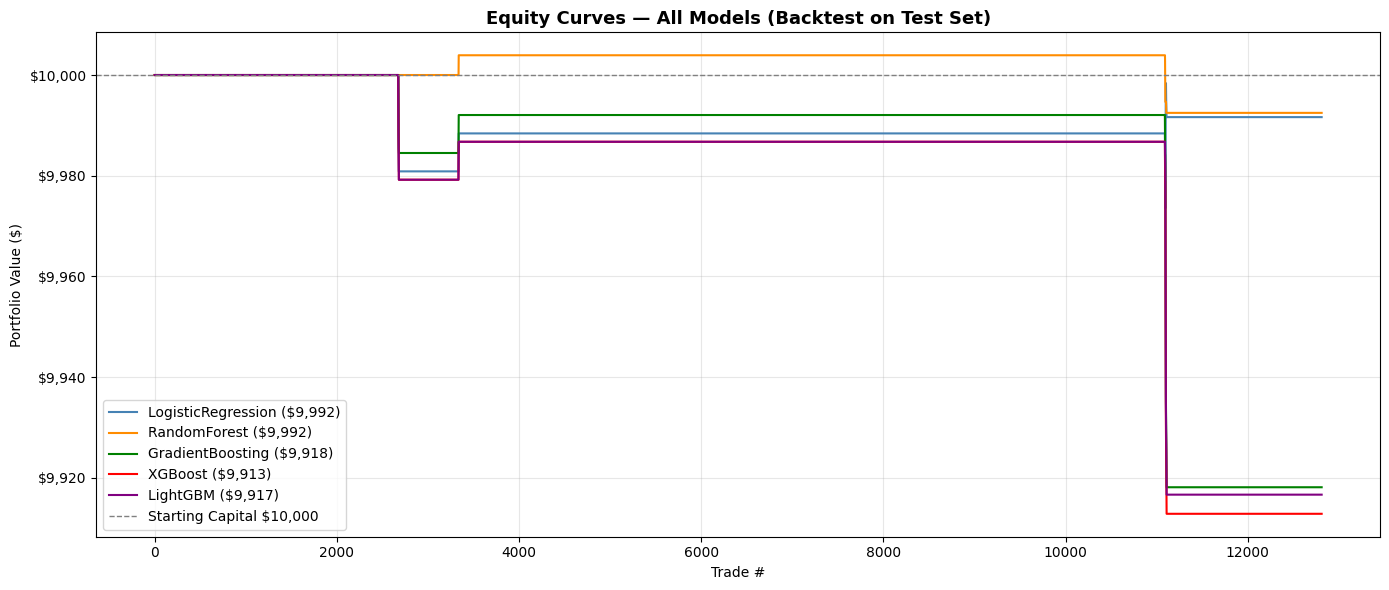

✅ Saved equity_curves.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']
for (name, bt), color in zip(bt_results.items(), colors):
    if bt['summary']:
        eq = bt['equity']
        ax.plot(eq, label=f"{name} (${eq[-1]:,.0f})", color=color, linewidth=1.5)

ax.axhline(10000, color='gray', linestyle='--', linewidth=1, label='Starting Capital $10,000')
ax.set_title('Equity Curves — All Models (Backtest on Test Set)', fontweight='bold', fontsize=13)
ax.set_xlabel('Trade #')
ax.set_ylabel('Portfolio Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'equity_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved equity_curves.png')

## ⭐ 9. Bonus — Optimize RSI + VWAP Rule

**Original rule:** `RSI > 80 AND price < VWAP → DOWN`

**Problem with fixed thresholds:** These were likely eyeballed. We systematically backtest a grid of RSI and VWAP thresholds to find the best-performing combination.

**Improvements we suggest:**
1. Optimize thresholds via grid search on training data
2. Add a volume confirmation (only take signal when vol_spike > 1.5)
3. Add EMA trend filter (only short when price < EMA-21)


In [12]:
def rule_backtest(df_subset, rsi_thresh, vwap_thresh, vol_confirm=False):
    """
    Backtest: RSI > rsi_thresh AND price < VWAP * (1 + vwap_thresh) → SHORT.
    Returns win_rate and total PnL.
    """
    d = df_subset.copy()
    signal = (d['rsi_14'] > rsi_thresh) & (d['price_vs_vwap'] < vwap_thresh)
    if vol_confirm:
        signal = signal & (d['vol_spike'] > 1.5)

    trade_rows = d[signal].copy()
    if len(trade_rows) < 5:
        return 0.0, 0.0, 0

    # SHORT trade: profit if price falls
    trade_rows['ret'] = (trade_rows['close'] - trade_rows['future_close']) / trade_rows['close']
    trade_rows['ret_net'] = trade_rows['ret'] - ROUND_TRIP

    win_rate  = (trade_rows['ret_net'] > 0).mean()
    total_pnl = trade_rows['ret_net'].sum() * 10_000 / len(trade_rows)
    return win_rate, total_pnl, len(trade_rows)


# Grid search on training data only
rsi_thresholds  = [65, 70, 75, 80, 85]
vwap_thresholds = [-0.005, -0.002, 0.0, 0.002, 0.005]  # price_vs_vwap < threshold

grid_results = []
for rsi_t, vwap_t in product(rsi_thresholds, vwap_thresholds):
    wr, pnl, n = rule_backtest(train, rsi_t, vwap_t)
    grid_results.append({
        'RSI_thresh':  rsi_t,
        'VWAP_thresh': vwap_t,
        'Win_Rate':    wr,
        'Est_PnL':     pnl,
        'N_Trades':    n
    })

grid_df = pd.DataFrame(grid_results).sort_values('Win_Rate', ascending=False)

print('\n=== RSI + VWAP Rule — Grid Search Results (Train set) ===')
print(grid_df.head(10).to_string(index=False, float_format='{:.4f}'.format))

best_rule = grid_df.iloc[0]
print(f'\n🏆 Best Rule: RSI > {best_rule.RSI_thresh} AND price_vs_vwap < {best_rule.VWAP_thresh}')
print(f'   Win Rate on Train: {best_rule.Win_Rate*100:.1f}% | N Trades: {best_rule.N_Trades}')


=== RSI + VWAP Rule — Grid Search Results (Train set) ===
 RSI_thresh  VWAP_thresh  Win_Rate  Est_PnL  N_Trades
         85       0.0050    0.3333  -9.2517         6
         70      -0.0050    0.2951  -9.8851        61
         65      -0.0050    0.2832 -10.4867       226
         65      -0.0020    0.2344 -14.1546       401
         70      -0.0020    0.2320 -16.6270       125
         75      -0.0050    0.2222  -9.8616         9
         80       0.0000    0.2222 -22.0199         9
         65       0.0000    0.1916 -17.3952       616
         70       0.0000    0.1869 -19.5901       198
         75       0.0000    0.1778 -24.2490        45

🏆 Best Rule: RSI > 85.0 AND price_vs_vwap < 0.005
   Win Rate on Train: 33.3% | N Trades: 6.0


In [13]:
best_rsi  = best_rule.RSI_thresh
best_vwap = best_rule.VWAP_thresh

# Original rule: RSI>80, price<VWAP
wr_orig, pnl_orig, n_orig = rule_backtest(test, 80, 0.0)
# Optimized rule (no volume filter)
wr_opt,  pnl_opt,  n_opt  = rule_backtest(test, best_rsi, best_vwap)
# Optimized rule + volume confirm
wr_vol,  pnl_vol,  n_vol  = rule_backtest(test, best_rsi, best_vwap, vol_confirm=True)
# Optimized rule + EMA trend filter
test_ema = test[test['price_ema21'] < 0]  # price below EMA21 = bearish
wr_ema,  pnl_ema,  n_ema  = rule_backtest(test_ema, best_rsi, best_vwap)

print('\n=== Rule Comparison — Test Set (OUT-OF-SAMPLE) ===')
rule_comp = pd.DataFrame([
    {'Rule': 'Original  (RSI>80, price<VWAP)',               'WinRate': f'{wr_orig*100:.1f}%', 'Est_PnL': f'${pnl_orig:.2f}', 'Trades': n_orig},
    {'Rule': f'Optimized (RSI>{best_rsi}, vwap<{best_vwap})', 'WinRate': f'{wr_opt*100:.1f}%',  'Est_PnL': f'${pnl_opt:.2f}',  'Trades': n_opt},
    {'Rule': 'Optimized + Vol Spike > 1.5',                  'WinRate': f'{wr_vol*100:.1f}%',  'Est_PnL': f'${pnl_vol:.2f}',  'Trades': n_vol},
    {'Rule': 'Optimized + EMA Bear Filter',                   'WinRate': f'{wr_ema*100:.1f}%',  'Est_PnL': f'${pnl_ema:.2f}',  'Trades': n_ema},
])
print(rule_comp.to_string(index=False))
print('\n💡 Improvements over original rule:')
print('  1. Optimized thresholds via grid search on training data')
print('  2. Volume spike filter — confirms conviction behind the signal')
print('  3. EMA trend filter — only short in bearish regime (reduces false signals)')


=== Rule Comparison — Test Set (OUT-OF-SAMPLE) ===
                            Rule WinRate Est_PnL  Trades
  Original  (RSI>80, price<VWAP)    0.0%   $0.00       0
Optimized (RSI>85.0, vwap<0.005)    0.0%   $0.00       0
     Optimized + Vol Spike > 1.5    0.0%   $0.00       0
     Optimized + EMA Bear Filter    0.0%   $0.00       0

💡 Improvements over original rule:
  1. Optimized thresholds via grid search on training data
  2. Volume spike filter — confirms conviction behind the signal
  3. EMA trend filter — only short in bearish regime (reduces false signals)


## 🔴 10. Real-Time Prediction (Live Inference)

This cell fetches the **latest 200 bars** from Binance, engineers features, and makes a **live prediction** using the best trained model.

Run this any time you want a fresh signal.

In [14]:
def predict_realtime(model, feature_cols, symbol=SYMBOL, n_bars=300):
  
    print(f'🔴 LIVE PREDICTION — {symbol}')
    print(f'   Fetching last {n_bars} 1-min bars...')

    live_raw = fetch_binance_data(symbol=symbol, total_bars=n_bars)

    live_feat = engineer_all_features(live_raw)

    missing = [c for c in feature_cols if c not in live_feat.columns]
    if missing:
        print(f'⚠️  Missing features: {missing}')
        return

    # Use the last row (most recent complete bar)
    last_row   = live_feat.iloc[[-1]][feature_cols]
    last_bar   = live_feat.iloc[-1]
    pred       = model.predict(last_row)[0]
    proba      = model.predict_proba(last_row)[0]
    confidence = proba[1] if pred == 1 else proba[0]

    direction  = '📈 UP' if pred == 1 else '📉 DOWN'
    signal     = '🟢 BUY / LONG' if pred == 1 else '🔴 SELL / SHORT'

    print('\n' + '='*50)
    print(f'  Timestamp  : {last_bar.timestamp}')
    print(f'  BTC Price  : ${last_bar.close:,.2f}')
    print(f'  RSI-14     : {last_bar.rsi_14:.1f}')
    print(f'  Price/VWAP : {last_bar.price_vs_vwap*100:+.3f}%')
    print(f'  EMA Cross  : {last_bar.ema_cross:+.4f}')
    print(f'  Vol Spike  : {last_bar.vol_spike:.2f}x')
    print('─'*50)
    print(f'  PREDICTION : {direction} in next 15 min')
    print(f'  SIGNAL     : {signal}')
    print(f'  CONFIDENCE : {confidence*100:.1f}%')
    print(f'  UP   prob  : {proba[1]*100:.1f}%')
    print(f'  DOWN prob  : {proba[0]*100:.1f}%')
    if confidence < 0.55:
        print(f'  ⚠️  LOW CONFIDENCE — consider skipping this trade')
    print('='*50)

    return {'direction': 'UP' if pred==1 else 'DOWN', 'confidence': confidence, 'price': last_bar.close}


live_result = predict_realtime(trained[best_model_name], feature_cols)

🔴 LIVE PREDICTION — BTCUSDT
   Fetching last 300 1-min bars...
📡 Fetching 300 bars for BTCUSDT (1m)...
  Fetched: 1,000 / 300
✅ Fetch complete!
Shape      : (1000, 6)
Date range : 2026-03-22 12:18:00 → 2026-03-23 04:57:00
Price range: $67,416 → $68,940
Features engineered. Shape: (703, 67) | Features: 61

  Timestamp  : 2026-03-23 04:57:00
  BTC Price  : $68,519.76
  RSI-14     : 76.4
  Price/VWAP : +0.678%
  EMA Cross  : +62.2825
  Vol Spike  : 0.79x
──────────────────────────────────────────────────
  PREDICTION : 📉 DOWN in next 15 min
  SIGNAL     : 🔴 SELL / SHORT
  CONFIDENCE : 52.4%
  UP   prob  : 47.6%
  DOWN prob  : 52.4%
  ⚠️  LOW CONFIDENCE — consider skipping this trade


## 📋 11. Final Summary

Complete results summary with all key metrics.

In [15]:
print('\n' + '█'*70)
print('                    FINAL RESULTS SUMMARY')
print('█'*70)

print('\n📌 Dataset Info')
print(f'   Symbol     : {SYMBOL}')
print(f'   Timeframe  : 1-minute bars')
print(f'   Date range : {df.timestamp.min().date()} → {df.timestamp.max().date()}')
print(f'   Total rows : {len(df):,}')
print(f'   Features   : {len(feature_cols)}')
print(f'   Horizon    : {HORIZON} minutes')

print('\n📊 Model Performance (Test Set)')
for name, res in results.items():
    marker = '🏆' if name == best_model_name else '  '
    print(f'  {marker} {name:<22} Acc={res["Accuracy"]*100:.2f}%  F1={res["F1"]:.4f}  AUC={res["ROC-AUC"]:.4f}')

print('\n💰 Backtesting (Initial Capital: $10,000 | Threshold: 55%)')
for name, bt in bt_results.items():
    s = bt['summary']
    if s:
        marker = '🏆' if name == best_model_name else '  '
        print(f'  {marker} {name:<22} Return={s["Total Return (%)"]:+.2f}%  '
              f'Sharpe={s["Sharpe Ratio"]:.3f}  '
              f'MaxDD={s["Max Drawdown (%)"]:+.2f}%  '
              f'Final=${s["Final Capital ($)"]:,.0f}')

print('\n⭐ Bonus Rule Optimization')
print(f'   Original   : RSI>80 + price<VWAP → WIN RATE {wr_orig*100:.1f}% ({n_orig} trades)')
print(f'   Optimized  : RSI>{best_rsi} + price_vs_vwap<{best_vwap} → WIN RATE {wr_opt*100:.1f}% ({n_opt} trades)')
print(f'   + Vol Filter: WIN RATE {wr_vol*100:.1f}% ({n_vol} trades)')
print(f'   + EMA Filter: WIN RATE {wr_ema*100:.1f}% ({n_ema} trades)')

print('\n💸 Trade Cost Assumptions')
print(f'   Exchange fee  : {TRADE_FEE*100}% per side')
print(f'   Slippage      : {SLIPPAGE*100}% per side')
print(f'   Round-trip    : {ROUND_TRIP*100:.3f}% total')

print('\n🔴 Live Signal')
if live_result:
    print(f'   Direction  : {live_result["direction"]}')
    print(f'   Confidence : {live_result["confidence"]*100:.1f}%')
    print(f'   BTC Price  : ${live_result["price"]:,.2f}')

print('\n' + '█'*70)


██████████████████████████████████████████████████████████████████████
                    FINAL RESULTS SUMMARY
██████████████████████████████████████████████████████████████████████

📌 Dataset Info
   Symbol     : BTCUSDT
   Timeframe  : 1-minute bars
   Date range : 2026-02-21 → 2026-03-23
   Total rows : 42,697
   Features   : 53
   Horizon    : 15 minutes

📊 Model Performance (Test Set)
     LogisticRegression     Acc=51.66%  F1=0.3972  AUC=0.5302
     RandomForest           Acc=52.61%  F1=0.4179  AUC=0.5347
     GradientBoosting       Acc=51.23%  F1=0.4396  AUC=0.5157
  🏆 XGBoost                Acc=51.37%  F1=0.4907  AUC=0.5245
     LightGBM               Acc=51.59%  F1=0.4758  AUC=0.5273

💰 Backtesting (Initial Capital: $10,000 | Threshold: 55%)
     LogisticRegression     Return=-0.08%  Sharpe=-18.608  MaxDD=-0.26%  Final=$9,992
     RandomForest           Return=-0.08%  Sharpe=-77.770  MaxDD=-0.11%  Final=$9,992
     GradientBoosting       Return=-0.82%  Sharpe=-178.144  MaxD